In [59]:
# here we are going to use postgres sql for store of LTM - also storing memories as embeddings.

In [60]:
from dotenv import load_dotenv
load_dotenv()

import os
import uuid
from typing import List
from pydantic import BaseModel, Field


from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.messages import HumanMessage,SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.config import RunnableConfig
from langgraph.store.postgres import PostgresStore
from langgraph.store.base import BaseStore,IndexConfig

In [61]:
# creating embedding model

EMBED_DIM = 1536

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    output_dimensionality=EMBED_DIM
)

test_vector = embeddings.embed_query("Testing Memory")
print("Embedding Dimensions: ",len(test_vector))

Embedding Dimensions:  1536


In [62]:
# persistent storage using PostgresStore

DB_URI = os.environ["DATABASE_URL"]

store_context = PostgresStore.from_conn_string(
    DB_URI,
    index= IndexConfig(
        dims=EMBED_DIM,
        embed=embeddings,
        fields=["data"],
    ),
)

store = store_context.__enter__()

# Creates the LangGraph store tables/indexes.
store.setup()

print("Store is ready..")

Store is ready..


In [63]:
# LLM 
LLM = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

In [64]:
# define schema

class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(
        description=(
            "True if this memory adds genuinely new information. "
            "False if it is duplicate or semantically equivalent "
            "to an existing memory."
        )
    )

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether any new long-term memory should be stored")
    memories: List[MemoryItem] = Field(
        default_factory=list,
        description="Atomic user memories to consider storing"
    )

In [65]:
# LLM with structured output..
memory_extractor = LLM.with_structured_output(MemoryDecision)

In [66]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.

If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, personalize your response when appropriate.

You may reference known:
- identity information
- stable preferences
- ongoing projects
- goals
- tools/frameworks the user uses

Do NOT invent or assume personal information.

Use only the memories supplied below.

At the end, suggest 3 relevant further questions based on the current
response and the user's known profile.

RELEVANT USER MEMORY:
{user_details_content}
"""

In [67]:
MEMORY_PROMPT = """You are responsible for maintaining accurate long-term user memory.

CURRENT RELEVANT USER MEMORIES:
{user_details_content}

TASK:
- Review the user's latest message.
- Extract only stable, user-specific information worth remembering long-term.
- Useful categories include identity, stable preferences, ongoing projects, goals,
  technical stack, learning interests, and other durable context.
- Do NOT store transient information such as greetings, one-time tasks, or the
  current conversation topic unless it represents stable user information.
- For each extracted memory, set is_new=true ONLY if it adds information that
  is not already present in the existing memories.
- Treat semantically equivalent statements as duplicates even if the wording differs.
- If the user corrects an existing fact, prefer the corrected fact rather than
  blindly creating another contradictory memory.
- Keep every memory short and atomic.
- Do not speculate.
- Only use facts explicitly stated by the user.
- If nothing is worth storing, return should_write=false and an empty list.
"""

In [68]:
# get latest human message
def get_latest_human_message(state:MessagesState) -> HumanMessage:
    for message in reversed(state["messages"]):
        if isinstance(message,HumanMessage):
            return message

    raise ValueError("No human message found in state..")

In [69]:
# memory extraction node
def remember_node(state:MessagesState, config:RunnableConfig, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    # latest user message
    last_message = get_latest_human_message(state)
    last_text = last_message.content

    # sementic retrival for duplicate detection..
    relavent_items = store.search(
        namespace,
        query=last_text,
        limit=8
    )

    existing_memory = "\n".join(item.value["data"] for item in relavent_items) if relavent_items else "(empty)"

    # Extract memories and detect semantic duplicates
    decision: MemoryDecision = memory_extractor.invoke([
        SystemMessage(content=SYSTEM_PROMPT_TEMPLATE.format(user_details_content = existing_memory)),
        last_message
    ])

    # Store only genuinely new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{"data":mem.text})

    return{}


In [70]:
# chat node
def chat_node(state:MessagesState, config:RunnableConfig, *, store:BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user",user_id,"details")

    last_message = get_latest_human_message(state)
    last_text = last_message.content

    relavent_items = store.search(
        namespace,
        query=last_text,
        limit=8
    )

    user_detail = "\n".join(f"- {item.value.get("data","")}" for item in relavent_items if item.value.get("data"))

    system_msg = SystemMessage(content=SYSTEM_PROMPT_TEMPLATE.format(user_details_content = user_detail or "(empty)"))

    response = LLM.invoke([system_msg] + state["messages"])
    return {"messages":[response]}

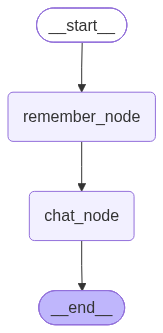

In [71]:
# building graph
graph_builder = StateGraph(MessagesState)

graph_builder.add_node("remember_node",remember_node)
graph_builder.add_node("chat_node",chat_node)

graph_builder.add_edge(START,"remember_node")
graph_builder.add_edge("remember_node","chat_node")
graph_builder.add_edge("chat_node",END)

graph = graph_builder.compile(store=store)

graph

In [72]:
# testing

In [73]:
config = {"configurable":{"user_id":"u1"}}

In [74]:
result = graph.invoke({"messages":[HumanMessage(content="hii my name is Aditya.")]},config)
print(result["messages"][-1].content)

Hello Aditya, it's nice to meet you. I already have a record of your name, so I can address you personally from the start. Is there something I can help you with or would you like to chat? 

Here are three questions to get us started: 
1. What brings you here today, Aditya?
2. Are you working on any projects that you'd like some assistance with?
3. Is there a specific topic you're interested in learning more about?


In [75]:
result = graph.invoke({"messages":[HumanMessage(content="I am currently learning Machine Learning and Artifical Intelligence.")]},config)
print(result["messages"][-1].content)

Hello Aditya, it's great to hear that you're making progress with Machine Learning and Artificial Intelligence. These are fascinating fields with a wide range of applications. What specific areas of Machine Learning and AI are you focusing on? Are you exploring supervised, unsupervised, or reinforcement learning, or perhaps delving into deep learning techniques like neural networks?

As you continue your learning journey, I'd be happy to help with any questions or topics you'd like to discuss. 

Here are three potential questions to consider:
1. What programming languages or frameworks (e.g., TensorFlow, PyTorch) are you using for your Machine Learning projects?
2. Are there any specific problems or industries (e.g., computer vision, natural language processing) where you'd like to apply your Machine Learning skills?
3. Have you come across any challenging concepts or topics in your studies that you'd like some help clarifying?


In [83]:
items = store.search(("user","u1","details"))

for item in items:
    print(item.value["data"])

Aditya has created a RAG based AI Chatbot as a project
Aditya is learning Machine Learning and Artificial Intelligence
User name is Aditya
User name is Aditya


In [78]:
result = graph.invoke({"messages":[HumanMessage(content="I am currently learning Machine Learning and Artifical Intelligence.")]},config)
print(result["messages"][-1].content)

Hello Aditya, it's great to hear that you're making progress with Machine Learning and Artificial Intelligence. These are fascinating fields with a wide range of applications. What specific areas of Machine Learning and AI are you currently focusing on? Are you exploring supervised, unsupervised, or reinforcement learning, or perhaps delving into deep learning techniques like neural networks?

As you continue your learning journey, I'd be happy to help with any questions or topics you'd like to discuss. 

Here are three potential further questions to consider:
1. What programming languages or frameworks are you using to implement your Machine Learning and AI projects?
2. Are there any specific industries or problems you're interested in applying Machine Learning and AI to?
3. Have you come across any challenging concepts or topics in your studies that you'd like some help clarifying?


In [80]:
result = graph.invoke({"messages":[HumanMessage(content="i have created a RAG based AI Chatbot as a project")]},config)
print(result["messages"][-1].content)

Hi Aditya, that's a great achievement. Creating a RAG (Retrieve, Augment, Generate) based AI Chatbot is a significant project, and it's wonderful that you've taken the initiative to work on it. RAG models are known for their ability to retrieve relevant information from a knowledge base and generate human-like responses.

As someone who's learning Machine Learning and Artificial Intelligence, this project is an excellent way to apply your knowledge and skills in a practical setting. I'm sure you've gained valuable insights into the capabilities and limitations of RAG models, as well as the challenges of fine-tuning and optimizing their performance.

How's your chatbot performing so far? Are there any specific features or functionalities you're planning to add or improve in the future?

Here are three relevant further questions:
1. What specific use case or application are you targeting with your RAG-based AI Chatbot?
2. How are you handling the knowledge retrieval and augmentation comp

In [82]:
result = graph.invoke({"messages":[HumanMessage(content="waht is my name and projects?")]},config)
print(result["messages"][-1].content)

Hello Aditya, your name is indeed Aditya. As for your projects, I recall that you have been working on a RAG (Retrieve, Augment, Generate) based AI Chatbot as one of your projects. You're also actively learning and exploring the fields of Machine Learning and Artificial Intelligence, which is great!

Here are three further questions that might be relevant to you:
1. What specific challenges are you facing in your RAG-based AI Chatbot project?
2. How do you think your knowledge of Machine Learning can be applied to enhance your chatbot's capabilities?
3. Are there any particular areas within Artificial Intelligence that you're most interested in exploring further?
